
# Restoring the second law to classical-quantum dynamics

This notebook contains the code and data used for plots in the paper by Isaac Layton and Harry Miller https://doi.org/10.48550/arXiv.2504.10587


The numerical runs for the paper used very large ensembles and the `ray` package. This notebook keeps a **serial** runner for portability. For exact paper-size runs e.g. R~20000, parallel execution is recommended.

In [1]:

from pathlib import Path
import math
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## Shared utilities for the underdamped oscillator model

In [2]:

def psi_from_x(x, c_list, q, M, mQ, w, hb):
    new_c_list = [c_list[n] / math.sqrt((2**n) * math.factorial(n)) for n in range(M)]
    prefactor = (mQ * w / (np.pi * hb)) ** 0.25
    gaussian = np.exp(-mQ * w * (x - q) * (x - q) / (2 * hb))
    arg = np.sqrt(mQ * w / hb) * (x - q)
    return gaussian * prefactor * np.polynomial.Hermite(new_c_list)(arg)


def c_decomp_q0(x, psi, M, mQ, w, hb):
    coeffs = np.polynomial.hermite.hermfit(
        math.sqrt(mQ * w / hb) * x,
        psi * np.exp(mQ * w * x * x / (2 * hb)) * math.sqrt(math.sqrt(np.pi * hb / (mQ * w))),
        M - 1,
    )
    return np.array(
        [coeffs[n] * math.sqrt((2**n) * math.factorial(n)) for n in range(M)],
        dtype=np.complex128,
    )


def top_modes(c_list, threshold=0.1):
    return [(float(np.abs(c_list[i]) ** 2), i) for i in range(len(c_list)) if np.abs(c_list[i]) ** 2 > threshold]


def number_state(model, n):
    c = np.zeros(model["M"], dtype=np.complex128)
    c[n] = 1.0
    return c


def displaced_ground_state(model, x0=1.0):
    c0 = number_state(model, 0)
    return sp.linalg.expm(-1j * x0 * model["P"]) @ c0


def prepare_underdamped_model(
    *, N, M, R, mQ=1.0, mC=1.0, w=1.0, hb=1.0, b=1.0, t_final=10.0, gm=1.0, Om=1.0
):
    lm = mQ * w * w / 2
    s = np.sqrt(2 * gm / b)
    xi = math.sqrt(lm / (2 * mQ)) * hb * b
    sinh_xi = np.sinh(xi)
    cosh_xi = np.cosh(xi)
    tanh_xi = np.tanh(xi)
    dt = t_final / N

    a = np.diag([math.sqrt(n) for n in range(1, M)], 1)
    ad = a.T
    n = ad @ a
    I = np.identity(M)

    Q = math.sqrt(hb / (2 * mQ * w)) * (a + ad)
    P = 1j * math.sqrt((hb * mQ * w) / 2) * (ad - a)

    Lq = (-2 * lm * sinh_xi / xi) * Q + (2j / (b * hb)) * (1 - cosh_xi) * P
    LqH = (-2 * lm * sinh_xi / xi) * Q - (2j / (b * hb)) * (1 - cosh_xi) * P

    K = -math.sqrt(b / (8 * gm)) * Lq
    KH = -math.sqrt(b / (8 * gm)) * LqH

    H = hb * w * (n + 0.5 * I)
    Qeff = (b / (8 * gm)) * (2 * mQ * w / (b * b * hb)) * (sinh_xi - tanh_xi) * (Q @ P + P @ Q)

    Keff = 0.5 * KH @ K
    Keff2 = 0.5 * K @ K
    Htot = H + Qeff

    return {
        "N": N, "M": M, "R": R, "mQ": mQ, "mC": mC, "w": w, "hb": hb,
        "b": b, "t_final": t_final, "gm": gm, "Om": Om, "lm": lm, "s": s,
        "xi": xi, "sinh_xi": sinh_xi, "cosh_xi": cosh_xi, "tanh_xi": tanh_xi,
        "dt": dt, "a": a, "ad": ad, "n": n, "I": I, "Q": Q, "P": P,
        "Lq": Lq, "LqH": LqH, "K": K, "KH": KH, "H": H, "Qeff": Qeff,
        "Keff": Keff, "Keff2": Keff2, "Htot": Htot,
    }


def K_av_real(c, model):
    val = -math.sqrt(model["b"] / (8 * model["gm"])) * (
        -2 * model["lm"] / model["xi"] * model["sinh_xi"] * np.vdot(c, model["Q"] @ c)
        + (2j / (model["b"] * model["hb"])) * (1 - model["cosh_xi"]) * np.vdot(c, model["P"] @ c)
    )
    return float(np.real(val))


def step_state(c, q, p, model, rng):
    dt = model["dt"]
    dW1 = rng.normal(loc=0.0, scale=np.sqrt(dt))
    Kavreal = K_av_real(c, model)

    M_mat = (
        model["I"]
        - (1j / model["hb"]) * (model["Htot"] - (p / model["mC"]) * model["P"]) * dt
        - model["Keff"] * dt
        + (2 * Kavreal * dt + dW1) * model["K"]
        + (dW1 * dW1 - dt) * model["Keff2"]
    )

    c = M_mat @ c
    c = c / np.sqrt(np.abs(np.vdot(c, c)))

    p = (
        p
        + np.sqrt((8 * model["gm"]) / model["b"]) * dt * Kavreal
        - p * (model["gm"] / model["mC"]) * dt
        + model["s"] * dW1
        - model["mC"] * model["Om"] * model["Om"] * q * dt
    )
    q = q + (p / model["mC"]) * dt
    return c, float(q), float(p)


def simulate_density_trajectory(model, c_initial, *, Nsamples, sigma_p=1e-6, sigma_q=0.0, seed=None):
    rng = np.random.RandomState(seed=seed)
    c = np.array(c_initial, dtype=np.complex128)
    p = float(rng.normal(loc=0.0, scale=sigma_p))
    q = float(rng.normal(loc=0.0, scale=sigma_q))
    stride = max(1, int(round(model["N"] / Nsamples)))
    out = []

    for i in range(1, model["N"] + 1):
        c, q, p = step_state(c, q, p, model, rng)
        if (i - 1) % stride == 0:
            rho = np.outer(np.conj(c), c).reshape(-1)
            out.append(np.concatenate([[q, p], rho]))

    return np.asarray(out)


def simulate_population_trajectory(model, c_initial, *, Nsamples, sigma_p=1e-3, sigma_q=1e-3, seed=None):
    rng = np.random.RandomState(seed=seed)
    c = np.array(c_initial, dtype=np.complex128)
    p = float(rng.normal(loc=0.0, scale=sigma_p))
    q = float(rng.normal(loc=0.0, scale=sigma_q))
    stride = max(1, int(round(model["N"] / Nsamples)))
    out = []

    for i in range(0, model["N"] + 1):
        if i % stride == 0:
            populations = np.real(np.conj(c) * c)
            out.append(np.concatenate([[q, p], populations]))
        if i == model["N"]:
            break
        c, q, p = step_state(c, q, p, model, rng)

    return np.asarray(out)


def run_many(simulator, model, c_initial, R, **kwargs):
    return np.asarray([simulator(model, c_initial, seed=seed, **kwargs) for seed in range(R)])


def mean_density_paths(ensemble, model):
    mean_path = ensemble.mean(axis=0)
    q_path = np.real(mean_path[:, 0])
    rho_path = mean_path[:, 2:].reshape(len(mean_path), model["M"], model["M"])
    q_rel = np.trace(rho_path @ model["Q"], axis1=1, axis2=2).real
    return q_path, q_path + q_rel, rho_path


def heat_change_from_density_ensemble(ensemble, model, sig_q, sig_p):
    q_initial = ensemble[:, 0, 0].real
    p_initial = ensemble[:, 0, 1].real
    q_final = ensemble[:, -1, 0].real
    p_final = ensemble[:, -1, 1].real

    rho_initial = ensemble[:, 0, 2:].reshape(len(ensemble), model["M"], model["M"])
    rho_final = ensemble[:, -1, 2:].reshape(len(ensemble), model["M"], model["M"])

    Q_quantum_initial = np.einsum("rij,ji->r", rho_initial, model["H"]).real
    Q_quantum_final = np.einsum("rij,ji->r", rho_final, model["H"]).real

    Q_classical_initial = (p_initial * p_initial) / (2 * model["mC"]) + (q_initial * q_initial * model["mC"] * model["Om"] * model["Om"] / 2)
    Q_classical_final = (p_final * p_final) / (2 * model["mC"]) + (q_final * q_final * model["mC"] * model["Om"] * model["Om"] / 2)

    Q_change = (Q_quantum_final + Q_classical_final) - (Q_quantum_initial + Q_classical_initial)

    DeltaS = (
        np.log(2)
        - np.log(model["b"] * model["Om"] * sig_q * sig_p)
        + (model["b"] * model["Om"] * model["hb"] / 2) * np.cosh((model["b"] * model["Om"] * model["hb"] / 2)) / np.sinh((model["b"] * model["Om"] * model["hb"] / 2))
        - np.log(2 * np.sinh((model["b"] * model["Om"] * model["hb"] / 2)))
    )

    return Q_change, DeltaS


## Figure 1

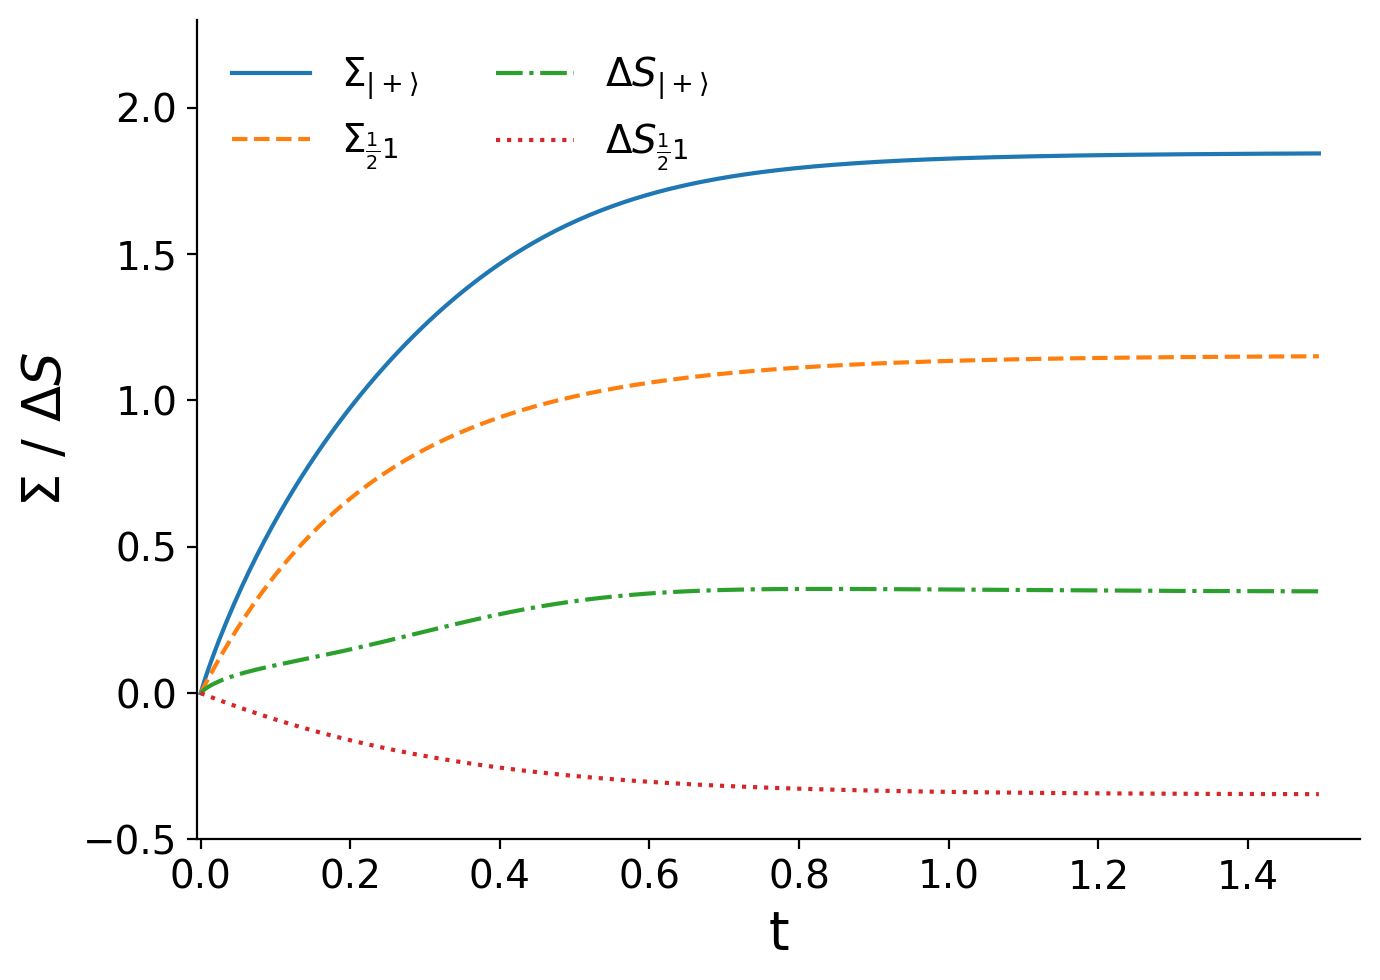

In [3]:

csv_path = Path("plotting_data.csv")

if not csv_path.exists():
    print("Figure 1 requires plotting_data.csv; that file was not uploaded.")
else:
    data = np.genfromtxt(csv_path, delimiter=",")
    t_list = np.arange(0.00001, 1.5, 0.005)

    fig, ax = plt.subplots(figsize=(7, 5), dpi=200)
    style_list = ["solid", "dashed", "dashdot", "dotted"]
    label_list = [
        r"$\Sigma_{|+\rangle}$",
        r"$\Sigma_{\frac{1}{2}1}$",
        r"$\Delta S_{|+\rangle}$",
        r"$\Delta S_{\frac{1}{2}1}$",
    ]

    for i in range(4):
        ax.plot(t_list, data.T[i], linestyle=style_list[i])

    ax.set_ylabel(r"$\Sigma\ /\ \Delta S$", fontsize=19)
    ax.set_xlabel("t", fontsize=19)
    ax.set_xlim(-0.005, 1.55)
    ax.set_ylim(-0.5, 2.3)
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.legend(label_list, fontsize=14, frameon=False, ncol=2)
    fig.tight_layout()
    plt.show()



## Figure 2

The next cells reproduce the three main pieces of Figure 2 using the parameter values from the paper captions, except with R=100.


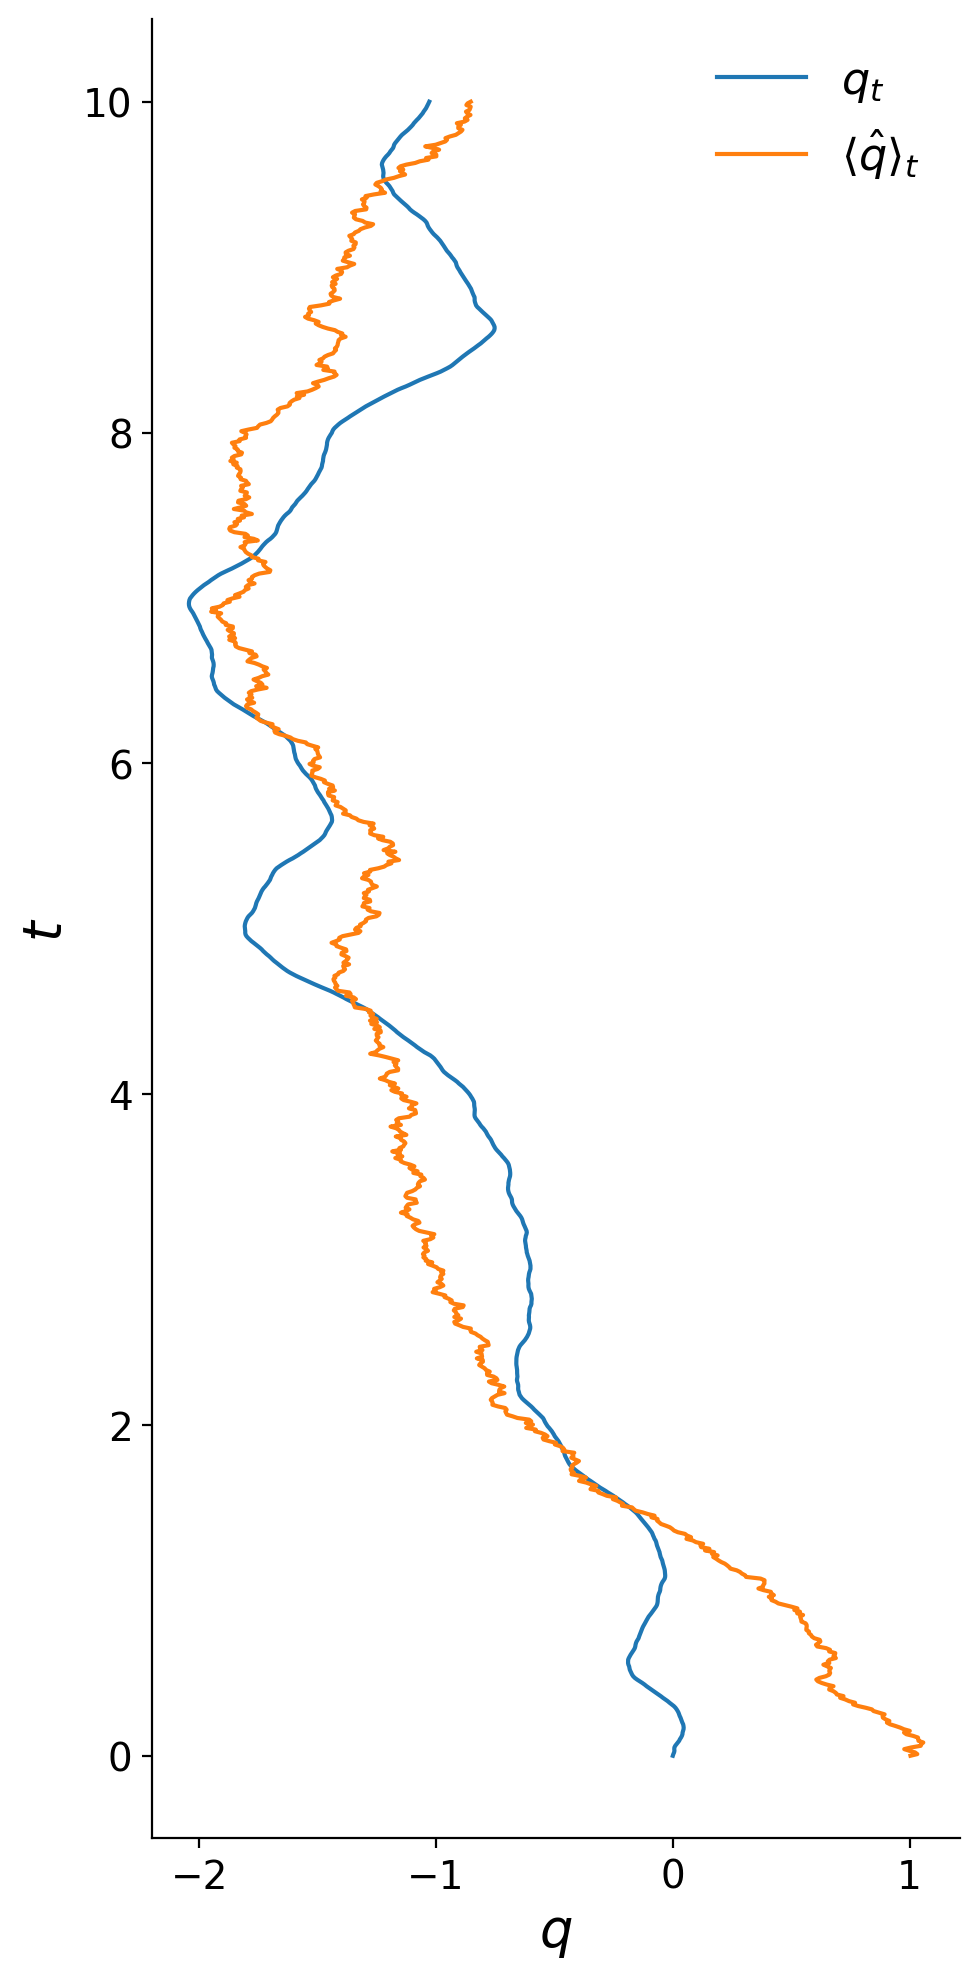

In [4]:

# Figure 2 (left): single trajectory
fig2_single = prepare_underdamped_model(
    N=20000, M=20, R=1, mQ=1, mC=1, w=1, hb=1, b=3, t_final=10, gm=3, Om=1e-5
)

c_initial_single = displaced_ground_state(fig2_single, x0=1.0)
single_path = simulate_density_trajectory(
    fig2_single, c_initial_single, Nsamples=1000, sigma_p=1e-6, sigma_q=0.0, seed=0
)

t = np.linspace(0, fig2_single["t_final"], len(single_path))
q_t = single_path[:, 0].real
rho_t = single_path[:, 2:].reshape(len(single_path), fig2_single["M"], fig2_single["M"])
qhat_t = q_t + np.trace(rho_t @ fig2_single["Q"], axis1=1, axis2=2).real

fig, ax = plt.subplots(figsize=(5, 10), dpi=200)
ax.plot(q_t, t)
ax.plot(qhat_t, t)
ax.set_xlabel(r"$q$", fontsize=19)
ax.set_ylabel(r"$t$", fontsize=19)
ax.set_ylim(-0.5, 10.5)
ax.legend([r"$q_t$", r"$\langle\hat{q}\rangle_t$"], fontsize=16, frameon=False)
ax.tick_params(axis="both", which="major", labelsize=14)
fig.tight_layout()
plt.show()


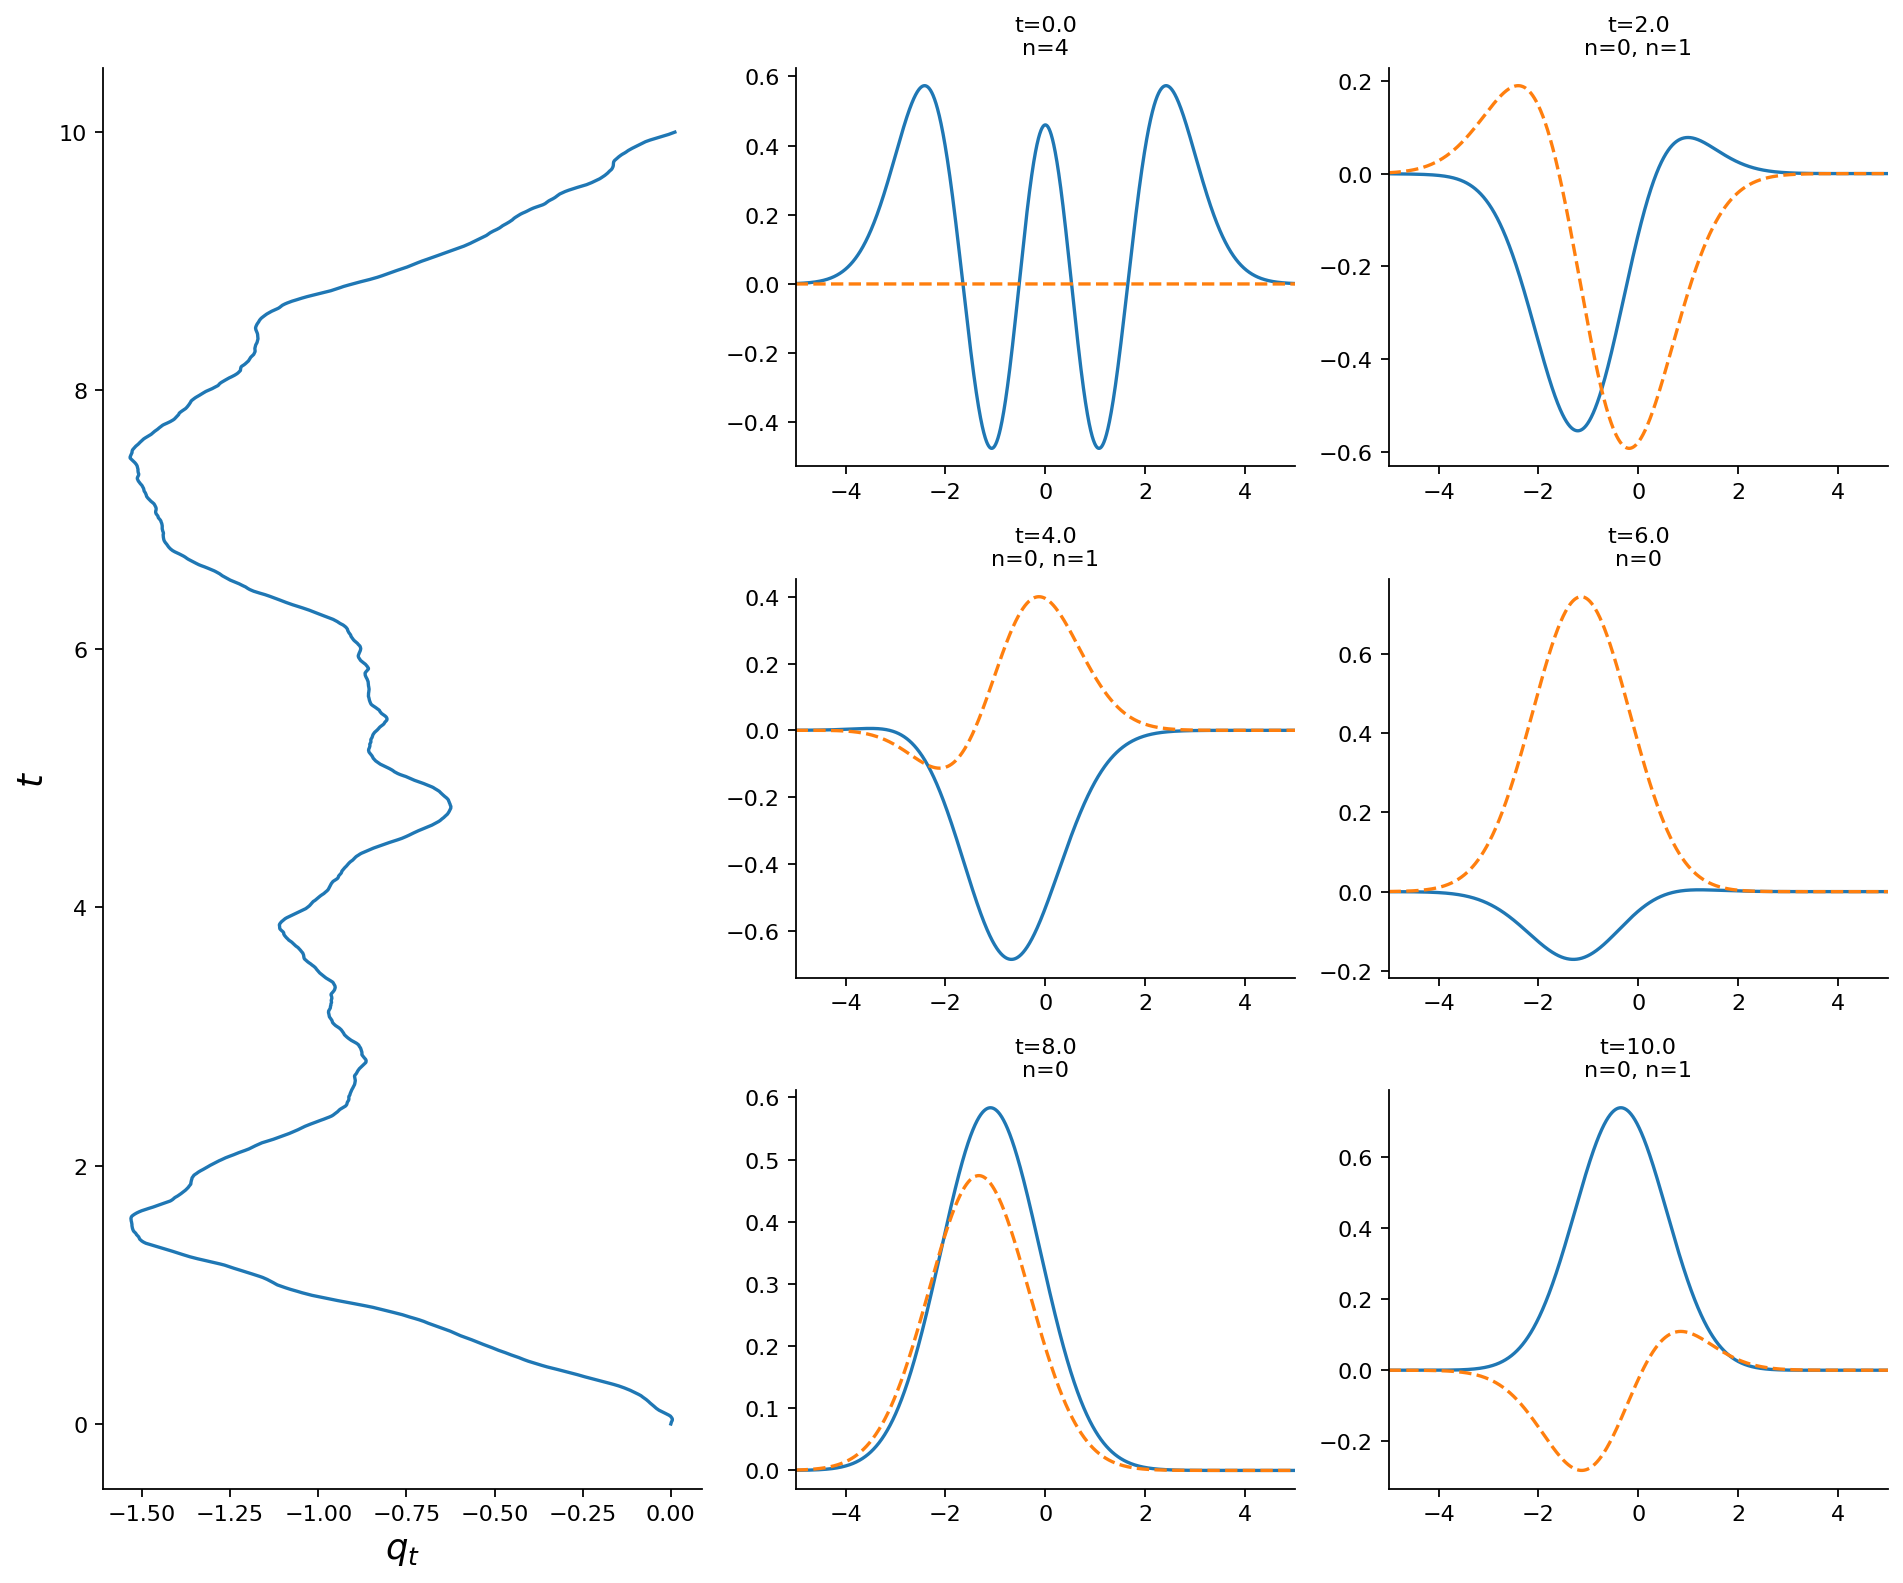

In [5]:

# Figure 2 (middle): wavefunction snapshots along one trajectory
fig2_snap = prepare_underdamped_model(
    N=100000, M=50, R=1, mQ=1, mC=1, w=1, hb=1, b=3, t_final=10, gm=3, Om=1e-5
)

c_snap = number_state(fig2_snap, 4)
rng = np.random.RandomState(0)
q = 0.0
p = 0.0

snapshot_times = np.linspace(0, fig2_snap["t_final"], 6)
snapshot_indices = set(np.round(snapshot_times / fig2_snap["dt"]).astype(int))

x_grid = np.linspace(-5, 5, 2000)
stored = []
q_trace = []
t_trace = []

for i in range(fig2_snap["N"] + 1):
    if i in snapshot_indices:
        stored.append((i * fig2_snap["dt"], q, np.array(c_snap, copy=True), top_modes(c_snap)))
    q_trace.append(q)
    t_trace.append(i * fig2_snap["dt"])
    if i == fig2_snap["N"]:
        break
    c_snap, q, p = step_state(c_snap, q, p, fig2_snap, rng)

fig = plt.figure(figsize=(12, 10), dpi=160)
gs = fig.add_gridspec(3, 3, width_ratios=[1.2, 1, 1])

ax_traj = fig.add_subplot(gs[:, 0])
ax_traj.plot(q_trace, t_trace)
ax_traj.set_xlabel(r"$q_t$", fontsize=16)
ax_traj.set_ylabel(r"$t$", fontsize=16)

for k, (time_k, q_k, c_k, modes_k) in enumerate(stored):
    row = k // 2
    col = 1 + (k % 2)
    ax = fig.add_subplot(gs[row, col])
    psi_k = psi_from_x(x_grid, c_k, q_k, fig2_snap["M"], fig2_snap["mQ"], fig2_snap["w"], fig2_snap["hb"])
    ax.plot(x_grid, np.real(psi_k))
    ax.plot(x_grid, np.imag(psi_k), linestyle="dashed")
    mode_text = ", ".join([f"n={mode}" for _, mode in modes_k]) if modes_k else "no mode > 0.1"
    ax.set_title(f"t={time_k:.1f}\n{mode_text}", fontsize=10)
    ax.set_xlim(-5, 5)

fig.tight_layout()
plt.show()


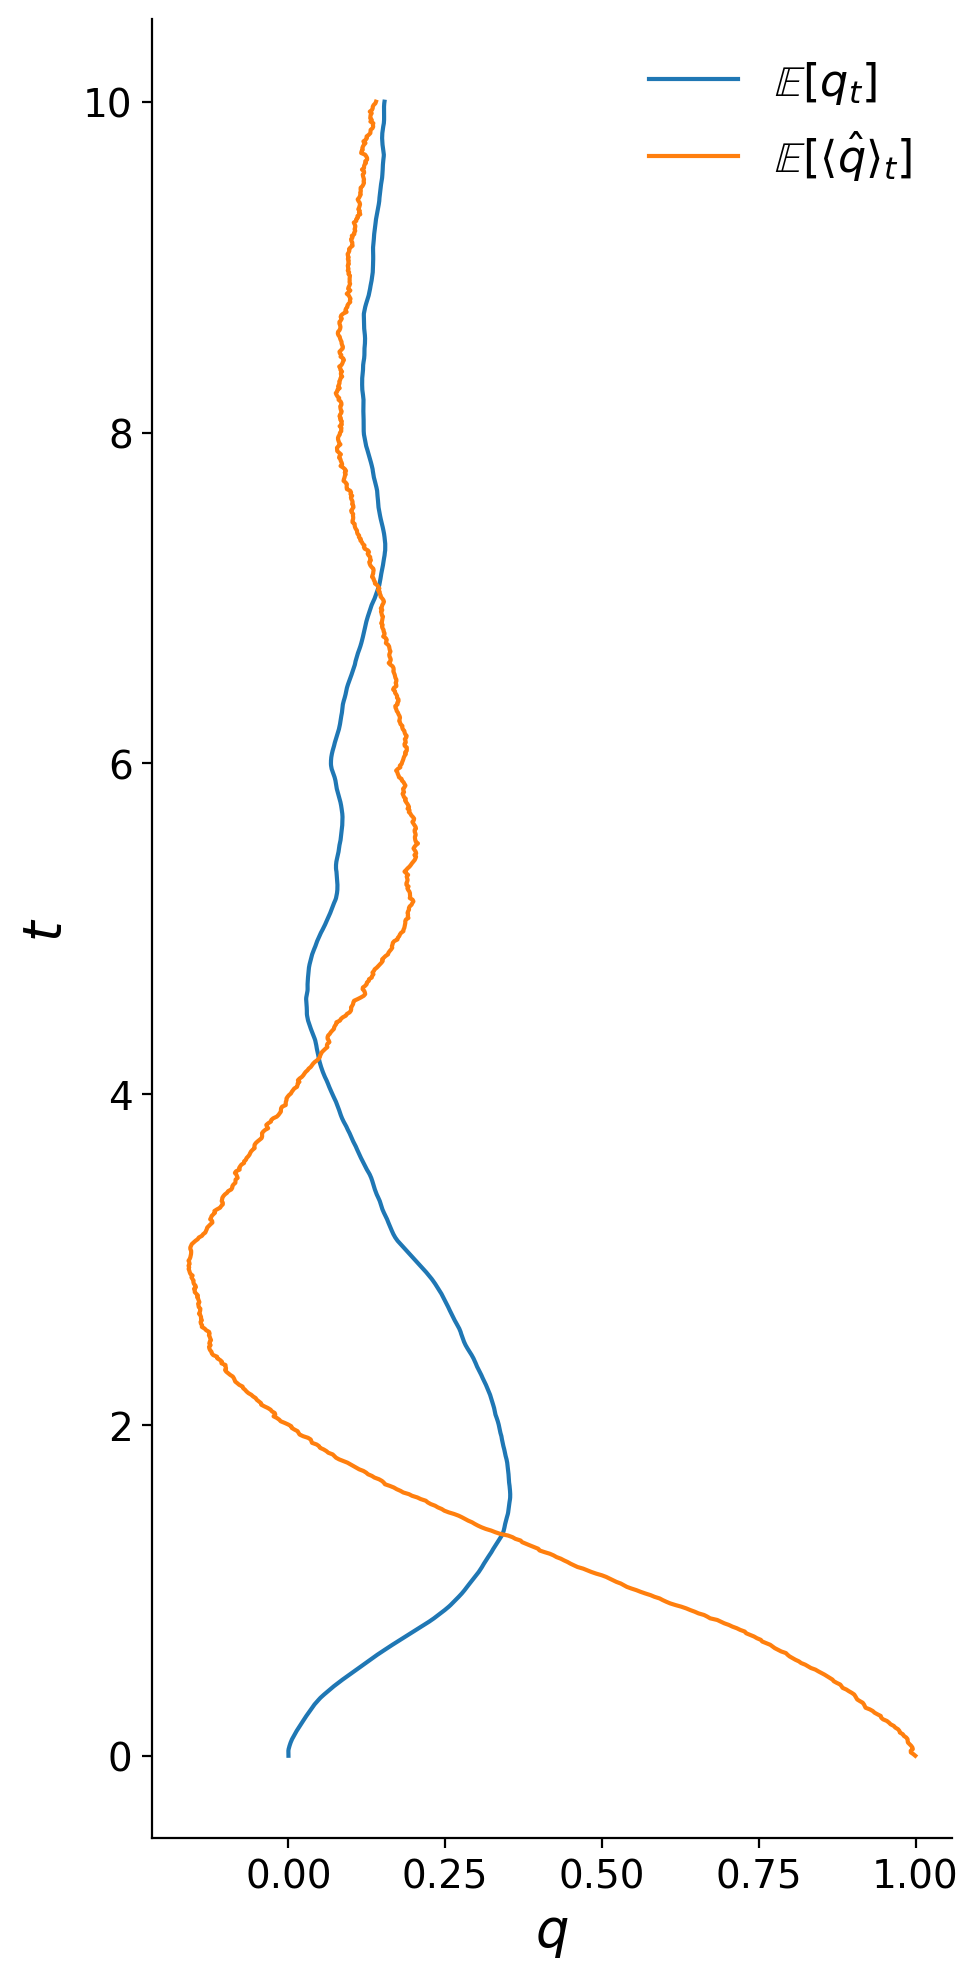

In [6]:

# Figure 2 (right): averaged trajectories
fig2_avg = prepare_underdamped_model(
    N=20000, M=20, R=100, mQ=1, mC=1, w=1, hb=1, b=3, t_final=10, gm=3, Om=1e-5
)

c_initial_avg = displaced_ground_state(fig2_avg, x0=1.0)

# This is expensive in serial mode at the paper value R=2000.
ensemble_avg = run_many(
    simulate_density_trajectory,
    fig2_avg,
    c_initial_avg,
    R=fig2_avg["R"],
    Nsamples=1000,
    sigma_p=1e-6,
    sigma_q=0.0,
)

t = np.linspace(0, fig2_avg["t_final"], ensemble_avg.shape[1])
q_mean, qhat_mean, _ = mean_density_paths(ensemble_avg, fig2_avg)

fig, ax = plt.subplots(figsize=(5, 10), dpi=200)
ax.plot(q_mean, t)
ax.plot(qhat_mean, t)
ax.set_xlabel(r"$q$", fontsize=19)
ax.set_ylabel(r"$t$", fontsize=19)
ax.set_ylim(-0.5, 10.5)
ax.legend([r"$\mathbb{E}[q_t]$", r"$\mathbb{E}[\langle\hat{q}\rangle_t]$"], fontsize=16, frameon=False)
ax.tick_params(axis="both", which="major", labelsize=14)
fig.tight_layout()
plt.show()


## Figure 3

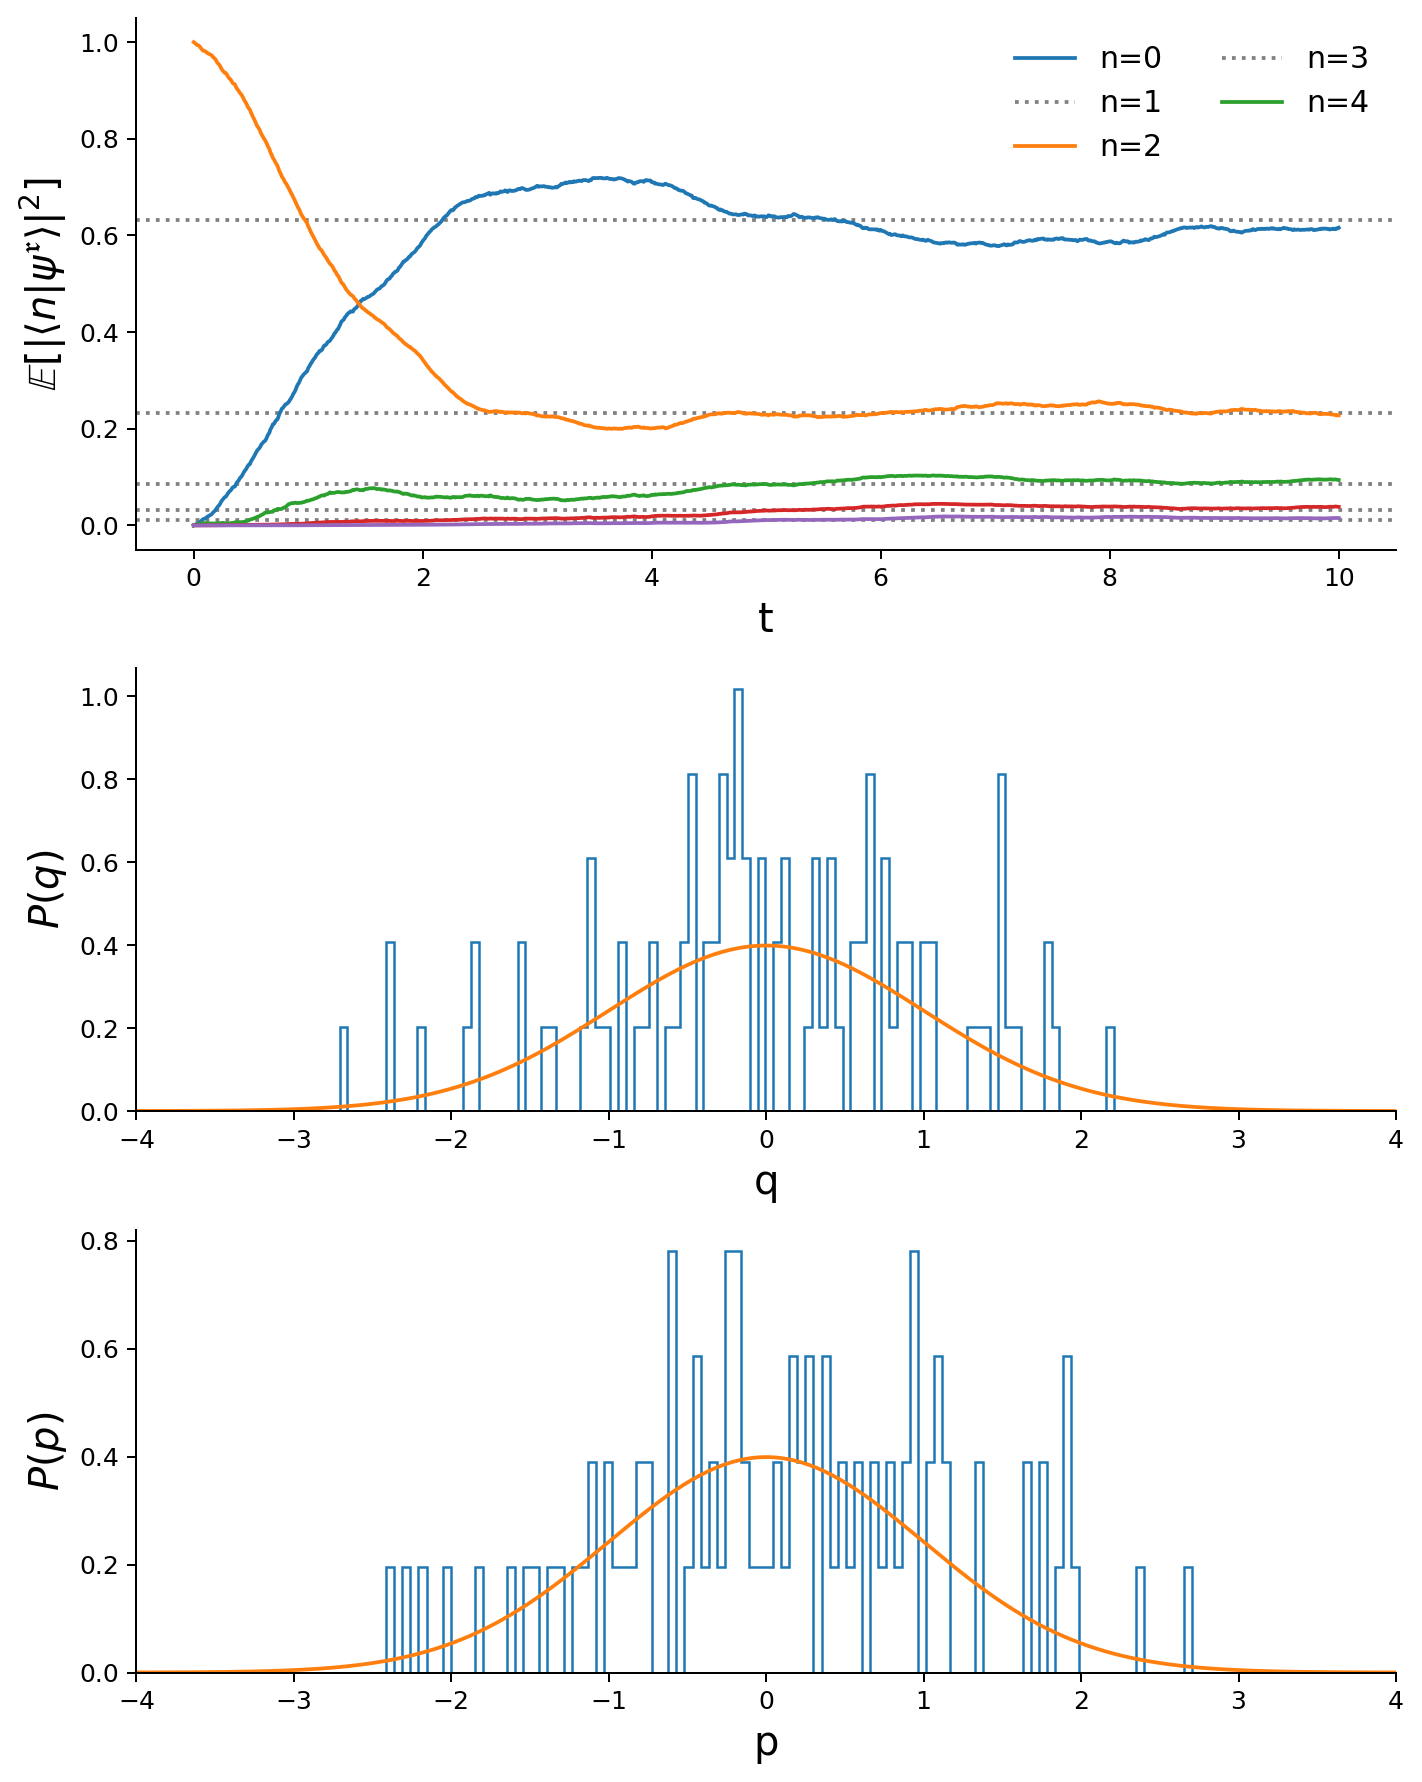

In [7]:

fig3_model = prepare_underdamped_model(
    N=5000, M=10, R=100, mQ=1, mC=1, w=1, hb=1, b=1, t_final=10, gm=1, Om=1
)

fig3_initial = number_state(fig3_model, 1)  # |psi^r>_0 = |1>
sig_q = 1e-3
sig_p = 1e-3

# This is expensive in serial mode at the paper value R=10000.
fig3_ensemble = run_many(
    simulate_population_trajectory,
    fig3_model,
    fig3_initial,
    R=fig3_model["R"],
    Nsamples=1000,
    sigma_p=sig_p,
    sigma_q=sig_q,
)

pop_list = fig3_ensemble[:, :, 2:].mean(axis=0)
q_final = fig3_ensemble[:, -1, 0].real
p_final = fig3_ensemble[:, -1, 1].real
t = np.linspace(0, fig3_model["t_final"], len(pop_list))

fig = plt.figure(figsize=(8, 10), dpi=180)
gs = fig.add_gridspec(3, 1, height_ratios=[1.2, 1, 1])

ax0 = fig.add_subplot(gs[0, 0])
for i in range(5):
    ax0.plot(t, pop_list[:, i])
    pi = np.exp(-fig3_model["hb"] * fig3_model["b"] * fig3_model["w"] * (i + 0.5)) / (
        np.exp(fig3_model["hb"] * fig3_model["b"] * fig3_model["w"] / 2) / (-1 + np.exp(fig3_model["hb"] * fig3_model["w"] * fig3_model["b"]))
    )
    ax0.axhline(y=pi, color="grey", linestyle="dotted", zorder=0)
ax0.set_ylabel(r"$\mathbb{E}[|\langle n | \psi^\mathfrak{r}\rangle|^2]$", fontsize=16)
ax0.set_xlabel("t", fontsize=16)
ax0.legend(["n=0", "n=1", "n=2", "n=3", "n=4"], fontsize=12, frameon=False, ncol=2)

ax1 = fig.add_subplot(gs[1, 0])
counts_q, bins_q = np.histogram(q_final, bins=100, density=True)
q_sample = np.linspace(-4, 4, 300)
ax1.stairs(counts_q, bins_q)
ax1.plot(
    q_sample,
    np.exp(-q_sample * q_sample * fig3_model["b"] * fig3_model["Om"] * fig3_model["Om"] * fig3_model["mC"] / 2)
    / np.sqrt(2 * np.pi / (fig3_model["b"] * fig3_model["Om"] * fig3_model["Om"] * fig3_model["mC"]))
)
ax1.set_ylabel(r"$P(q)$", fontsize=16)
ax1.set_xlabel("q", fontsize=16)
ax1.set_xlim(-4, 4)

ax2 = fig.add_subplot(gs[2, 0])
counts_p, bins_p = np.histogram(p_final, bins=100, density=True)
p_sample = np.linspace(-4, 4, 300)
ax2.stairs(counts_p, bins_p)
ax2.plot(
    p_sample,
    np.exp(-p_sample * p_sample * fig3_model["b"] / (2 * fig3_model["mC"]))
    / np.sqrt(2 * np.pi * fig3_model["mC"] / fig3_model["b"])
)
ax2.set_ylabel(r"$P(p)$", fontsize=16)
ax2.set_xlabel("p", fontsize=16)
ax2.set_xlim(-4, 4)

fig.tight_layout()
plt.show()


## Figure 4

In [8]:

def plot_heat_distribution(*, N, M, R, b, gm, t_final, sig_q, sig_p, Om=1, title=None):
    model = prepare_underdamped_model(
        N=N, M=M, R=R, mQ=1, mC=1, w=1, hb=1, b=b, t_final=t_final, gm=gm, Om=Om
    )
    c0 = number_state(model, 0)  # adiabatic ground state

    ensemble = run_many(
        simulate_density_trajectory,
        model,
        c0,
        R=model["R"],
        Nsamples=1000,
        sigma_p=sig_p,
        sigma_q=sig_q,
    )

    Q_change, DeltaS = heat_change_from_density_ensemble(ensemble, model, sig_q, sig_p)

    fig, ax = plt.subplots(figsize=(7, 3.5), dpi=180)
    counts, bins = np.histogram(Q_change, bins=180)
    ax.stairs(counts, bins)
    ax.axvline(np.mean(Q_change), color="orange")
    ax.axvline(DeltaS / model["b"], color="red", linestyle="dotted")
    ax.set_xlabel(r"$Q_t$", fontsize=16)
    ax.set_ylabel("counts", fontsize=16)
    if title is not None:
        ax.set_title(title, fontsize=12)
    fig.tight_layout()
    plt.show()

    return model, ensemble, Q_change, DeltaS


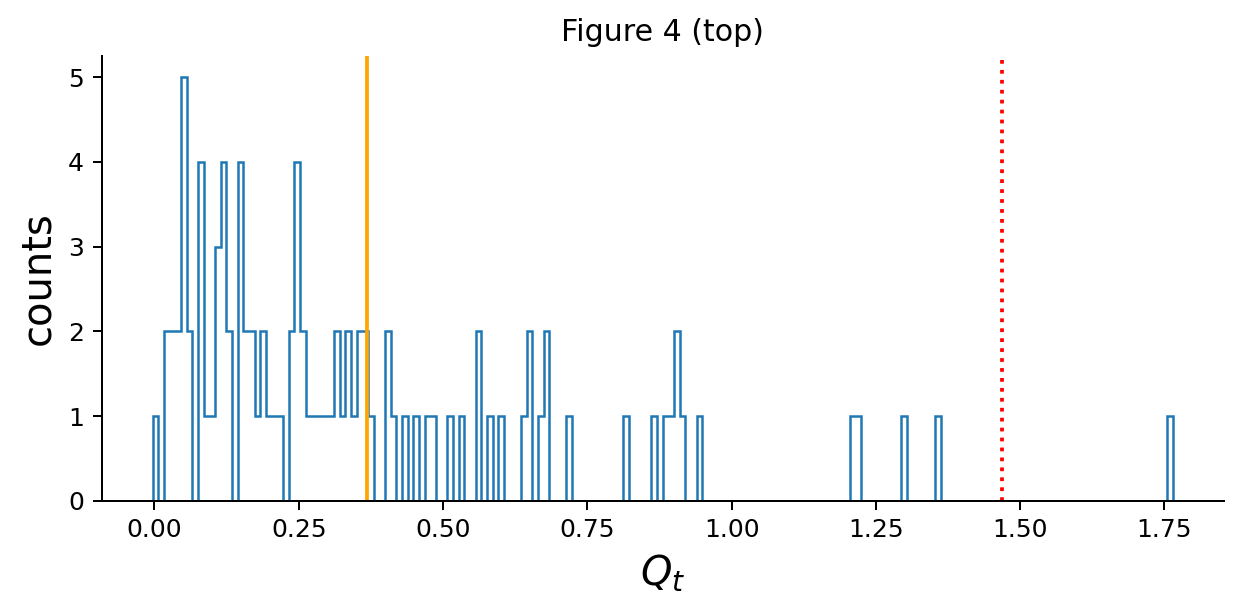

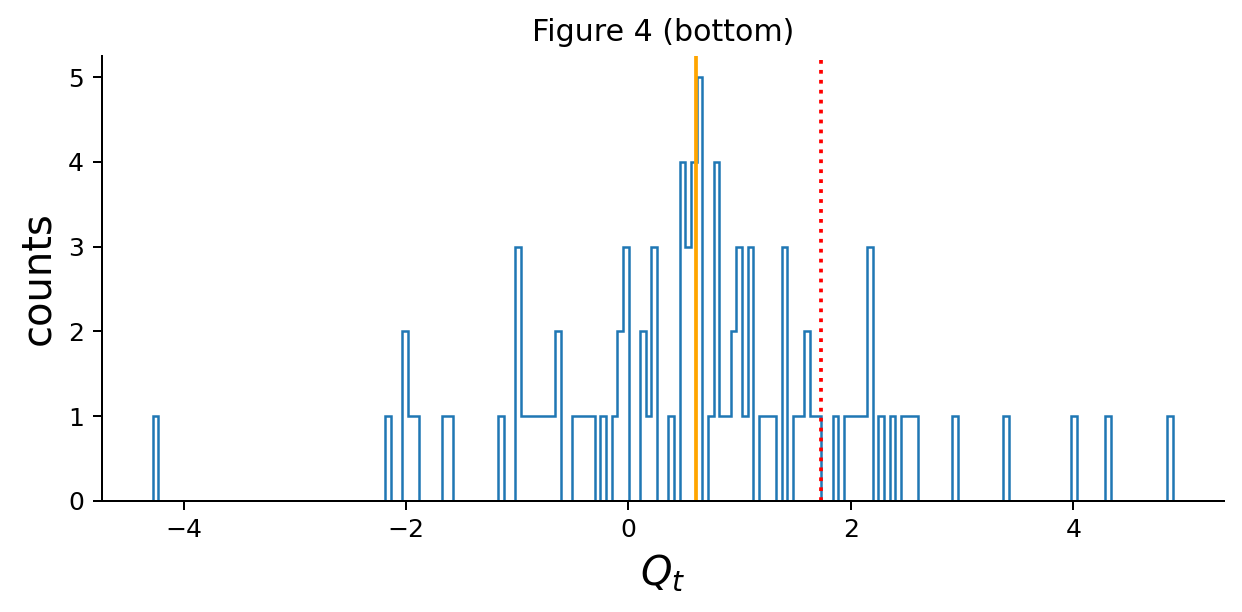

In [9]:

# Figure 4 (top)
fig4_top_model, fig4_top_ensemble, fig4_top_Q, fig4_top_DeltaS = plot_heat_distribution(
    N=5000, M=10, R=100, b=3, gm=3, t_final=10, sig_q=0.1, sig_p=0.1, Om=1, title="Figure 4 (top)"
)

# Figure 4 (bottom)
fig4_bot_model, fig4_bot_ensemble, fig4_bot_Q, fig4_bot_DeltaS = plot_heat_distribution(
    N=10000, M=10, R=100, b=1, gm=1, t_final=20, sig_q=1.0, sig_p=1.0, Om=1, title="Figure 4 (bottom)"
)
